In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Input, Activation, BatchNormalization,Dropout
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import keras
from tensorflow.keras import layers, models

2025-03-17 12:36:56.485439: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [24]:
file_path = '../data/X_test.npy'
X_test = np.load(file_path)
file_path = '../data/y_test.npy'
y_test = np.load(file_path)
file_path = '../data/X_train.npy'
X_train = np.load(file_path)
file_path = '../data/y_train.npy'
y_train = np.load(file_path)
sizes = np.load('../data/sizes.npy')


In [ ]:
# Pie chart, where the slices will be ordered and plotted counter-clockwise:
labels = ['SF', 'Comp', 'AGN', 'Liner']

#colors
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Class Distribution')
plt.show()


In [3]:
keras.backend.clear_session()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train_split = scaler.transform(X_train_split)

X_val_split = scaler.transform(X_val_split)
X_test = scaler.transform(X_test)

p_dropout=0.5

keras.backend.clear_session()


inputs = layers.Input(shape=(8,))

fc1 = layers.Dense(256, name="fc1", kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
fc1 = layers.Activation(activation="relu")(fc1)
fc1 = layers.Dropout(p_dropout)(fc1)
fc1 = layers.BatchNormalization(axis=-1)(fc1)

fc2 = layers.Dense(256, name="fc2", kernel_regularizer=keras.regularizers.l2(0.01))(fc1)
fc2 = layers.Activation(activation="relu")(fc2)
fc2 = layers.Dropout(p_dropout)(fc2)
fc2 = layers.BatchNormalization(axis=-1)(fc2)

fc3 = layers.Dense(256, name="fc3", kernel_regularizer=keras.regularizers.l2(0.01))(fc2)
fc3 = layers.Activation(activation="relu")(fc3)
fc3 = layers.Dropout(p_dropout)(fc3)
fc3 = layers.BatchNormalization(axis=-1)(fc3)

fc4 = layers.Dense(256, name="fc4", kernel_regularizer=keras.regularizers.l2(0.01))(fc3)
fc4 = layers.Activation(activation="relu")(fc4)
fc4 = layers.Dropout(p_dropout)(fc4)
fc4 = layers.BatchNormalization(axis=-1)(fc4)

skip_connection = fc1  

combined_input = layers.Add()([fc4, skip_connection])
fc5 = layers.Dense(256, name="fc5", kernel_regularizer=keras.regularizers.l2(0.01))(combined_input)
fc5 = layers.Activation(activation="relu")(fc5)
fc5 = layers.Dropout(p_dropout)(fc5)
fc5 = layers.BatchNormalization(axis=-1)(fc5)

output = layers.Dense(4, activation='softmax')(fc5)

model = models.Model(inputs=inputs, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │      2,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ fc1[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ fc2[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc3 (Dense)         │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256)       │          0 │ fc3[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc4 (Dense)         │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ fc4[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dropout_3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc5 (Dense)         │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 256)       │          0 │ fc5[0][0]       

 Total params: 271,620 (1.04 MB)

 Trainable params: 269,060 (1.03 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [4]:
#implement changing learning rate
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.losses import binary_crossentropy
import tensorflow as tf
from tensorflow.keras import backend as ops

def lr_schedule(epoch, lr):
    return 0.00001 if epoch >= 5 else 0.001

lr_callback = LearningRateScheduler(lr_schedule)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

model_history = model.fit(X_train_split, y_train_split, epochs=15, batch_size=16, verbose=1, shuffle=True, validation_data=(X_val_split, y_val_split),callbacks=[lr_callback])

Epoch 1/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5410 - loss: 10.7146 - val_accuracy: 0.7956 - val_loss: 7.8935 - learning_rate: 0.0010
Epoch 2/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7516 - loss: 7.4180 - val_accuracy: 0.8131 - val_loss: 5.7353 - learning_rate: 0.0010
Epoch 3/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7813 - loss: 5.4436 - val_accuracy: 0.8251 - val_loss: 4.2611 - learning_rate: 0.0010
Epoch 4/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7796 - loss: 4.0912 - val_accuracy: 0.8295 - val_loss: 3.2147 - learning_rate: 0.0010
Epoch 5/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7980 - loss: 3.0968 - val_accuracy: 0.8372 - val_loss: 2.4304 - learning_rate: 0.0010
Epoch 6/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8028 - loss: 2.5205 - val_accuracy: 0.8404 - val_loss: 2.4152 - learning_rate: 1.0000e-05
Epoch 7/15
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8037 - loss:

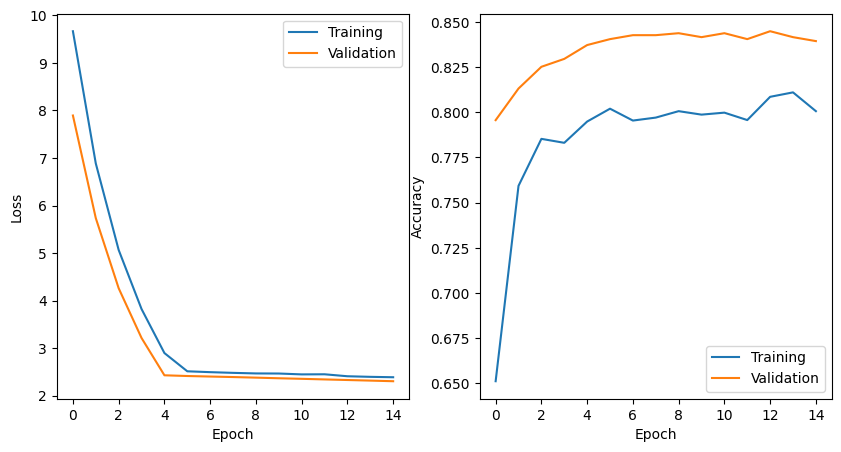

In [5]:
import sys
sys.path.append('..')
import plotting


plotting.plot_model_history(model_history)

In [6]:
pred = model.predict(X_test,verbose=0)


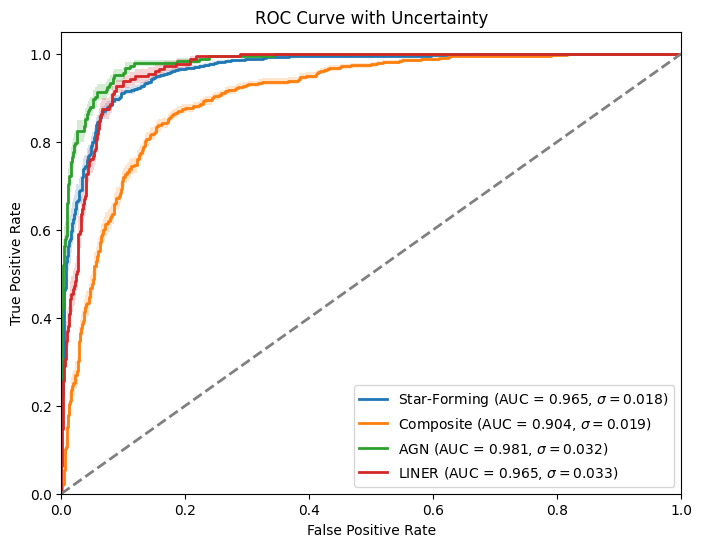

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

def monte_carlo_predictions(model, X, num_samples=50):
    """
    Performs Monte Carlo Dropout inference to estimate model uncertainty.
    """
    preds = np.array([model(X, training=True).numpy() for _ in range(num_samples)])  
    return preds 

num_mc_samples = 50
mc_preds = monte_carlo_predictions(model, X_test, num_mc_samples)

y_pred_prob = np.mean(mc_preds[:, :, :4], axis=0)
y_pred_uncertainty = np.std(mc_preds[:, :, :4], axis=0) 

fpr = {}
tpr = {}
roc_auc = {}
tpr_uncertainty = {}

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    tpr_samples = []
    for j in range(num_mc_samples):
        fpr_sample, tpr_sample, _ = roc_curve(y_test[:, i], mc_preds[j, :, i])
        
        interp_func = interp1d(fpr_sample, tpr_sample, kind='linear', fill_value='extrapolate')
        tpr_samples.append(interp_func(fpr[i]))

    tpr_samples = np.array(tpr_samples)
    tpr_uncertainty[i] = np.std(tpr_samples, axis=0) 

plt.figure(figsize=(8, 6))
classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

for i in range(4):
    #check for nan values and remove them
    for n in tpr_uncertainty[i]:
        if np.isnan(n):
            tpr_uncertainty[i] = np.delete(tpr_uncertainty[i], np.where(np.isnan(tpr_uncertainty[i])))
            fpr[i] = np.delete(fpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            tpr[i] = np.delete(tpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            break
    plt.plot(fpr[i], tpr[i], lw=2, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}, $\sigma = ${tpr_uncertainty[i].mean():.3f})')
    
    min_len = min(len(tpr[i]), len(tpr_uncertainty[i])) 
    plt.fill_between(
    fpr[i][:min_len], 
    tpr[i][:min_len] - tpr_uncertainty[i][:min_len],
    tpr[i][:min_len] + tpr_uncertainty[i][:min_len],  
    alpha=0.2)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Uncertainty')
plt.legend(loc='lower right')
plt.savefig('../plots/NN-ROC_Curves.pdf', format='pdf')
plt.show()



In [8]:
model.save('NN_model.keras')

# Intermediate Redshift Galaxies (0.32<z<0.8)

We now test our trained model on the intermediate redshift galaxy dataset to see how it performs.

In [27]:
#test the model on intermediate redshift

file_path_features = '../data/X_extra_data.npy'
X_test = np.load(file_path_features)
file_path_labels = '../data/labels_extra_data.npy'
Y_test = np.load(file_path_labels)
Y_test = np.array(Y_test, dtype=int)

#standardize the data
scaler = StandardScaler()
X_test = scaler.fit_transform(X_test)

#remove feature [:,2]
X_test = np.delete(X_test, 2, 1)

In [28]:
print((Y_test))

[[1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 0 1 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [0 1 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]

In [33]:
old_model = keras.models.load_model('NN_model.keras')
old_weights = old_model.get_weights()

p_dropout = 0.4

new_model = keras.Sequential()
inputs = layers.Input(shape=(7,))

fc1 = layers.Dense(256, name="fc1", kernel_regularizer=keras.regularizers.l2(0.01))(inputs)
fc1 = layers.Activation(activation="relu")(fc1)
fc1 = layers.Dropout(p_dropout)(fc1)
fc1 = layers.BatchNormalization(axis=-1)(fc1)

fc2 = layers.Dense(256, name="fc2", kernel_regularizer=keras.regularizers.l2(0.01))(fc1)
fc2 = layers.Activation(activation="relu")(fc2)
fc2 = layers.Dropout(p_dropout)(fc2)
fc2 = layers.BatchNormalization(axis=-1)(fc2)

fc3 = layers.Dense(256, name="fc3", kernel_regularizer=keras.regularizers.l2(0.01))(fc2)
fc3 = layers.Activation(activation="relu")(fc3)
fc3 = layers.Dropout(p_dropout)(fc3)
fc3 = layers.BatchNormalization(axis=-1)(fc3)

fc4 = layers.Dense(256, name="fc4", kernel_regularizer=keras.regularizers.l2(0.01))(fc3)
fc4 = layers.Activation(activation="relu")(fc4)
fc4 = layers.Dropout(p_dropout)(fc4)
fc4 = layers.BatchNormalization(axis=-1)(fc4)

skip_connection = fc1  

combined_input = layers.Add()([fc4, skip_connection])
fc5 = layers.Dense(256, name="fc5", kernel_regularizer=keras.regularizers.l2(0.01))(combined_input)
fc5 = layers.Activation(activation="relu")(fc5)
fc5 = layers.Dropout(p_dropout)(fc5)
fc5 = layers.BatchNormalization(axis=-1)(fc5)

output = layers.Dense(4, activation='softmax')(fc5)

new_model = models.Model(inputs=inputs, outputs=output)

new_weights = new_model.get_weights() 

# Transfer weights from old model to new model (manually skipping first layer)
for i in range(1, len(new_weights)):  
    new_weights[i] = old_weights[i]  # Offset to match layers correctly

# Assign weights to new model
new_model.set_weights(new_weights)

for layer in new_model.layers:
    layer.trainable = False 

new_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

new_model.summary(show_trainable=True)



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5     │ (None, 7)       │         0 │ -              │   -   │
│ (InputLayer)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc1 (Dense)       │ (None, 256)     │     2,048 │ input_layer_5… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_25     │ (None, 256)     │         0 │ fc1[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_25        │ (None, 256)     │         0 │ activation_25… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256)     │     1,024 │ dropout_25[0]… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc2 (Dense)       │ (None, 256)     │    65,792 │ batch_normali… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_26     │ (None, 256)     │         0 │ fc2[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_26        │ (None, 256)     │         0 │ activation_26… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256)     │     1,024 │ dropout_26[0]… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc3 (Dense)       │ (None, 256)     │    65,792 │ batch_normali… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_27     │ (None, 256)     │         0 │ fc3[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_27        │ (None, 256)     │         0 │ activation_27… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256)     │     1,024 │ dropout_27[0]… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ fc4 (Dense)       │ (None, 256)     │    65,792 │ batch_normali… │   N   │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ activation_28     │ (None, 256)     │         0 │ fc4[0][0]      │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ dropout_28        │ (None, 256)     │         0 │ activation_28… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ batch_normalizat… │ (None, 256)     │     1,024 │ dropout_28[0]… │   N   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ add_5 (Add)       │ (None, 256)     │         0 │ batch_normali… │   -   │
│                   │                 │           │ batch_normali… │     

 Total params: 271,364 (1.04 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 271,364 (1.04 MB)

In [34]:
pred = new_model.predict(X_test,verbose=0)
print(np.argmax(pred, axis=1))
print(np.argmax(Y_test, axis=1))


#calculate accuracy
from sklearn.metrics import accuracy_score
y_pred = np.argmax(pred, axis=1)
y_true = np.argmax(Y_test, axis=1)
accuracy = accuracy_score(y_true, y_pred)
print(accuracy)

#calculate confusion matrix
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0]
[0 1 0 0 0 1 0 0 0 1 0 0 2 0 1 1 0 0 0 1 0 0 0 0 0 3 0 0 0 0 0 0 1 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 1 1 0 0 0 0 2
 0 0 0 0 2 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 2 0 1 0 0 0 0 1 0 0 0 0 0
 0 0 1 2 0 0 0 0 3 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 1 0]
0.7727272727272727


array([[119,   0,   0,   0],
       [ 27,   0,   0,   0],
       [  6,   0,   0,   0],
       [  2,   0,   0,   0]])

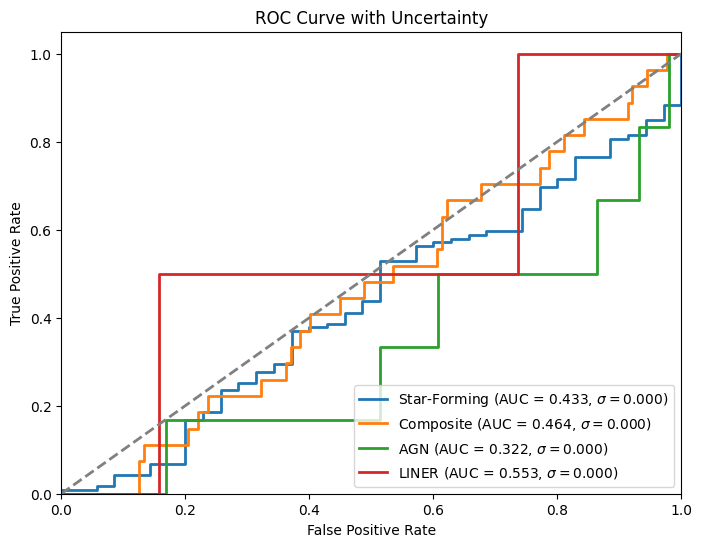

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

fpr = {}
tpr = {}
roc_auc = {}
tpr_uncertainty = {}

def monte_carlo_predictions(model, X, num_samples=50):
    """
    Performs Monte Carlo Dropout inference to estimate model uncertainty.
    """
    preds = np.array([model(X, training=False).numpy() for _ in range(num_samples)])  
    return preds 

num_mc_samples = 50
mc_preds = monte_carlo_predictions(new_model, X_test, num_mc_samples)

y_pred_prob = np.mean(mc_preds[:, :, :4], axis=0)
y_pred_uncertainty = np.std(mc_preds[:, :, :4], axis=0) 

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    tpr_samples = []
    for j in range(num_mc_samples):
        fpr_sample, tpr_sample, _ = roc_curve(Y_test[:, i], mc_preds[j, :, i])
        
        interp_func = interp1d(fpr_sample, tpr_sample, kind='linear', fill_value='extrapolate')
        tpr_samples.append(interp_func(fpr[i]))

    tpr_samples = np.array(tpr_samples)
    tpr_uncertainty[i] = np.std(tpr_samples, axis=0) 

plt.figure(figsize=(8, 6))
classes = ['Star-Forming', 'Composite', 'AGN', 'LINER']

for i in range(4):
    #check for nan values and remove them
    for n in tpr_uncertainty[i]:
        if np.isnan(n):
            tpr_uncertainty[i] = np.delete(tpr_uncertainty[i], np.where(np.isnan(tpr_uncertainty[i])))
            fpr[i] = np.delete(fpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            tpr[i] = np.delete(tpr[i], np.where(np.isnan(tpr_uncertainty[i])))
            break
    plt.plot(fpr[i], tpr[i], lw=2, label=rf'{classes[i]} (AUC = {roc_auc[i]:.3f}, $\sigma = ${tpr_uncertainty[i].mean():.3f})')
    
    min_len = min(len(tpr[i]), len(tpr_uncertainty[i])) 
    plt.fill_between(
    fpr[i][:min_len], 
    tpr[i][:min_len] - tpr_uncertainty[i][:min_len],
    tpr[i][:min_len] + tpr_uncertainty[i][:min_len],  
    alpha=0.2)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Uncertainty')
plt.legend(loc='lower right')
plt.savefig('../plots/INT-NN-ROC_Curves.pdf', format='pdf')
plt.show()